`conda activate cellcharter`

In [1]:
import anndata as ad
import squidpy as sq
import pandas as pd
import scanpy as sc
import numpy as np
import seaborn as sb
import matplotlib.pyplot as plt
import matplotlib as mpl
import scipy.io
import os
import cell2location

/home/cruiz2/miniconda3/envs/cellcharter/lib/python3.10/site-packages/pandas/core/computation/expressions.py:21: UserWarning: Pandas requires version '2.8.4' or newer of 'numexpr' (version '2.7.3' currently installed).
  from pandas.core.computation.check import NUMEXPR_INSTALLED


In [2]:
mpl.rcParams["figure.figsize"] = (5, 5)
mpl.rcParams['pdf.fonttype'] = 42

In [3]:
adata = sc.read('sp.h5ad')

In [4]:
adata

AnnData object with n_obs × n_vars = 16185 × 15284
    obs: 'in_tissue', 'array_row', 'array_col', 'sample', 'n_genes_by_counts', 'log1p_n_genes_by_counts', 'total_counts', 'log1p_total_counts', 'pct_counts_in_top_50_genes', 'pct_counts_in_top_100_genes', 'pct_counts_in_top_200_genes', 'pct_counts_in_top_500_genes', '_indices', '_scvi_batch', '_scvi_labels', 'AC_like', 'Astrocyte', 'B_cell', 'COP_like', 'Cilia_like', 'Endothelial', 'GB_like', 'GW_like', 'Mono_neutrophil', 'Mural', 'Neuron', 'OPC', 'OPC_like', 'Oligodendrocyte', 'RG_like', 'TAM_C1Q', 'TAM_IL1B', 'TAM_homeostatic', 'TAM_lipid_laden', 'TAM_scavenger', 'TD_like', 'T_cell', 'Tri_IPC_like', 'nIPC_like', 'total RNA counts', 'Total cell abundance (sum_f w_sf)', 'RNA detection sensitivity (y_s)', 'mean_nUMI_factorsfact_0', 'mean_nUMI_factorsfact_1', 'mean_nUMI_factorsfact_2', 'mean_nUMI_factorsfact_3', 'mean_nUMI_factorsfact_4', 'mean_nUMI_factorsfact_5', 'mean_nUMI_factorsfact_6', 'mean_nUMI_factorsfact_7', 'mean_nUMI_factorsf

In [5]:
adata = adata[ ~adata.obs['sample'].isin(['DMG1'])].copy()
adata

AnnData object with n_obs × n_vars = 11848 × 15284
    obs: 'in_tissue', 'array_row', 'array_col', 'sample', 'n_genes_by_counts', 'log1p_n_genes_by_counts', 'total_counts', 'log1p_total_counts', 'pct_counts_in_top_50_genes', 'pct_counts_in_top_100_genes', 'pct_counts_in_top_200_genes', 'pct_counts_in_top_500_genes', '_indices', '_scvi_batch', '_scvi_labels', 'AC_like', 'Astrocyte', 'B_cell', 'COP_like', 'Cilia_like', 'Endothelial', 'GB_like', 'GW_like', 'Mono_neutrophil', 'Mural', 'Neuron', 'OPC', 'OPC_like', 'Oligodendrocyte', 'RG_like', 'TAM_C1Q', 'TAM_IL1B', 'TAM_homeostatic', 'TAM_lipid_laden', 'TAM_scavenger', 'TD_like', 'T_cell', 'Tri_IPC_like', 'nIPC_like', 'total RNA counts', 'Total cell abundance (sum_f w_sf)', 'RNA detection sensitivity (y_s)', 'mean_nUMI_factorsfact_0', 'mean_nUMI_factorsfact_1', 'mean_nUMI_factorsfact_2', 'mean_nUMI_factorsfact_3', 'mean_nUMI_factorsfact_4', 'mean_nUMI_factorsfact_5', 'mean_nUMI_factorsfact_6', 'mean_nUMI_factorsfact_7', 'mean_nUMI_factorsf

In [6]:
nmf_df = pd.DataFrame(adata.uns['mod_coloc_n_fact7']['post_sample_means']['location_factors'])
nmf_df.index = adata.uns['mod_coloc_n_fact7']['obs_names']
nmf_df.columns = adata.uns['mod_coloc_n_fact7']['fact_names']
nmf_df.head()

,fact_0,fact_1,fact_2,fact_3,fact_4,fact_5,fact_6
BT01_192_core_HE/outs/_AAACAGTGTTCCTGGG-1,0.0,0.000000,0.0,0.083814,0.226187,0.0,0.000000
BT01_192_core_HE/outs/_AAACCGGGTAGGTACC-1,0.0,0.038803,0.0,0.103664,0.114554,0.0,0.000000
BT01_192_core_HE/outs/_AAACCGTTCGTCCAGG-1,0.0,0.000000,0.0,0.120920,0.097331,0.0,0.020564
BT01_192_core_HE/outs/_AAACCTCATGAAGTTG-1,0.0,0.023437,0.0,0.110779,0.048015,0.0,0.171610
BT01_192_core_HE/outs/_AAACGAGACGGTTGAT-1,0.0,0.000000,0.0,0.098536,0.408341,0.0,0.000000


In [ ]:
# Ensure that 'nmf_df' index and 'adata.obs_names' are aligned in type (e.g., strings)
nmf_df = nmf_df.loc[adata.obs_names]
nmf_df

In [ ]:
nmf_df = nmf_df.loc[:,['fact_0', 'fact_2', 'fact_4', 'fact_1', 'fact_6']]
nmf_df

In [ ]:
nmf_normalized = nmf_df.div(nmf_df.sum(axis=1), axis=0)
nmf_normalized

In [10]:
# Step 3: Extract spatial data (from `obsm` attribute)
# Assuming spatial data is stored in `adata.obsm['spatial']`
xy_df = pd.DataFrame(adata.obsm['spatial'], columns=['x', 'y'])
xy_df.index = adata.obs_names  # Match row names with observation names

# Step 5: Export both dataframes to CSV
xy_output_path = "spatial_data.csv"
nmf_output_path = "nmf_data.csv"

xy_df.to_csv(xy_output_path)
nmf_normalized.to_csv(nmf_output_path)

# Print the output file paths
print(f"Spatial data saved to: {xy_output_path}")
print(f"NMF data saved to: {nmf_output_path}")

Spatial data saved to: spatial_data.csv
NMF data saved to: nmf_data.csv


In [11]:
nmf_df['max_factor'] = nmf_df.idxmax(axis=1)
nmf_df.head()

,fact_0,fact_2,fact_4,fact_1,fact_6,max_factor
spot_id,,,,,,
BT01_192_core_HE/outs/_AAACAGTGTTCCTGGG-1,0.0,0.0,0.226187,0.000000,0.000000,fact_4
BT01_192_core_HE/outs/_AAACCGGGTAGGTACC-1,0.0,0.0,0.114554,0.038803,0.000000,fact_4
BT01_192_core_HE/outs/_AAACCGTTCGTCCAGG-1,0.0,0.0,0.097331,0.000000,0.020564,fact_4
BT01_192_core_HE/outs/_AAACCTCATGAAGTTG-1,0.0,0.0,0.048015,0.023437,0.171610,fact_6
BT01_192_core_HE/outs/_AAACGAGACGGTTGAT-1,0.0,0.0,0.408341,0.000000,0.000000,fact_4


In [12]:
# Step 1: Ensure obs_names in adata match the index in nmf_df
if (nmf_df.index == adata.obs_names).all():
    print("Indexes match!")
else:
    print("Warning: Indexes do not match, please reorder or check!")

# Step 2: Add the max_factor column to adata.obs
adata.obs['max_factor'] = nmf_df['max_factor'].values

# Verify it was added
adata.obs.head()

Indexes match!


,in_tissue,array_row,array_col,sample,n_genes_by_counts,log1p_n_genes_by_counts,total_counts,log1p_total_counts,pct_counts_in_top_50_genes,pct_counts_in_top_100_genes,...,mean_nUMI_factorsfact_6,mean_nUMI_factorsfact_7,mean_nUMI_factorsfact_8,mean_nUMI_factorsfact_9,mean_nUMI_factorsfact_10,mean_nUMI_factorsfact_11,mean_nUMI_factorsfact_12,mean_nUMI_factorsfact_13,mean_nUMI_factorsfact_14,max_factor
spot_id,,,,,,,,,,,,,,,,,,,,,
BT01_192_core_HE/outs/_AAACAGTGTTCCTGGG-1,1,73,43,BT01_192_core_HE,3845,8.254789,9634.0,9.173158,21.351464,28.139921,...,1.478956,0.000000,0.0,0.0,0.000000,0.522885,0.0,0.000000,0.0,fact_4
BT01_192_core_HE/outs/_AAACCGGGTAGGTACC-1,1,42,28,BT01_192_core_HE,3607,8.190909,9569.0,9.166389,23.910544,31.476643,...,1.563863,0.005317,0.0,0.0,0.088299,0.140116,0.0,0.000000,0.0,fact_4
BT01_192_core_HE/outs/_AAACCGTTCGTCCAGG-1,1,52,42,BT01_192_core_HE,3303,8.102889,8040.0,8.992309,23.644279,30.472637,...,1.755234,0.065163,0.0,0.0,0.000000,0.053763,0.0,0.000000,0.0,fact_4
BT01_192_core_HE/outs/_AAACCTCATGAAGTTG-1,1,37,19,BT01_192_core_HE,2716,7.907284,6225.0,8.736489,23.180723,30.907631,...,0.837298,0.508212,0.0,0.0,0.054470,0.000000,0.0,0.054273,0.0,fact_6
BT01_192_core_HE/outs/_AAACGAGACGGTTGAT-1,1,35,79,BT01_192_core_HE,1491,7.307873,2782.0,7.931285,26.491733,34.974838,...,0.168988,0.000000,0.0,0.0,0.000000,1.428918,0.0,0.111628,0.0,fact_4


In [13]:
cts = ['RG_like','Tri_IPC_like','nIPC_like','OPC_like', # Stem-niche
      'COP_like','AC_like','TAM_scavenger','TAM_homeostatic','OPC', #AC/MG
      'TD_like','GW_like','GB_like', 'TAM_lipid_laden','TAM_C1Q', # hypoxia/stress
      'Mono_neutrophil','Neuron','B_cell','Cilia_like',
      'Endothelial','Mural', 'TAM_IL1B','T_cell',
      'Oligodendrocyte', 'Astrocyte']

In [14]:
# Define the samples classified as 'diagnosis'
relapse_samples = ['BT01_192_core_HE', 'VUMC_17_pons_HE', 'VUMC_11_pons_HE']

# Create a new column in adata.obs for classification
adata.obs['treatment'] = adata.obs['sample'].apply(lambda x: 'relapse' if x in relapse_samples else 'diagnosis')

# Verify the addition
adata.obs[['sample', 'treatment']].head()

,sample,treatment
spot_id,,
BT01_192_core_HE/outs/_AAACAGTGTTCCTGGG-1,BT01_192_core_HE,relapse
BT01_192_core_HE/outs/_AAACCGGGTAGGTACC-1,BT01_192_core_HE,relapse
BT01_192_core_HE/outs/_AAACCGTTCGTCCAGG-1,BT01_192_core_HE,relapse
BT01_192_core_HE/outs/_AAACCTCATGAAGTTG-1,BT01_192_core_HE,relapse
BT01_192_core_HE/outs/_AAACGAGACGGTTGAT-1,BT01_192_core_HE,relapse


In [15]:
adata.obs['sampleID'] = adata.obs['sample']

adata.obs['Niche_NMF'] = adata.obs['max_factor']

In [16]:
tab = sc.get.obs_df(adata, keys= ["sampleID","Niche_NMF","treatment"]+ cts)
tab

,sampleID,Niche_NMF,treatment,RG_like,Tri_IPC_like,nIPC_like,OPC_like,COP_like,AC_like,TAM_scavenger,...,Mono_neutrophil,Neuron,B_cell,Cilia_like,Endothelial,Mural,TAM_IL1B,T_cell,Oligodendrocyte,Astrocyte
spot_id,,,,,,,,,,,,,,,,,,,,,
BT01_192_core_HE/outs/_AAACAGTGTTCCTGGG-1,BT01_192_core_HE,fact_4,relapse,0.021343,0.000577,0.000264,0.003829,0.049919,0.037373,0.111147,...,0.000898,0.001166,0.000685,0.003585,0.010324,0.013355,0.007721,0.001446,0.066556,0.005033
BT01_192_core_HE/outs/_AAACCGGGTAGGTACC-1,BT01_192_core_HE,fact_4,relapse,0.146086,0.000589,0.000110,0.000441,0.009161,0.014664,0.001914,...,0.008610,0.002127,0.103529,0.031192,0.001841,0.147082,0.000674,0.001893,0.001790,0.046993
BT01_192_core_HE/outs/_AAACCGTTCGTCCAGG-1,BT01_192_core_HE,fact_4,relapse,0.034471,0.001196,0.000193,0.001001,0.065087,0.085740,0.030406,...,0.001099,0.001679,0.001018,0.112046,0.000144,0.049133,0.000832,0.001089,0.000950,0.021041
BT01_192_core_HE/outs/_AAACCTCATGAAGTTG-1,BT01_192_core_HE,fact_6,relapse,0.037238,0.000351,0.000052,0.000127,0.000589,0.010911,0.016402,...,0.001963,0.016388,0.081774,0.359850,0.000051,0.180938,0.002721,0.000327,0.001238,0.136919
BT01_192_core_HE/outs/_AAACGAGACGGTTGAT-1,BT01_192_core_HE,fact_4,relapse,0.002676,0.001632,0.001150,0.002234,0.013317,0.055440,0.004203,...,0.003271,0.019448,0.001879,0.033703,0.000720,0.006513,0.002155,0.001038,0.005949,0.206932
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
DMG5_TTGTGTTTCCCGAAAG-1,DMG5,fact_1,diagnosis,0.601690,0.235197,0.006226,0.164946,0.081588,0.811372,0.031711,...,0.021417,0.001853,0.006854,0.003325,0.721555,1.579541,0.009543,0.045397,0.001212,0.040396
DMG5_TTGTTCAGTGTGCTAC-1,DMG5,fact_4,diagnosis,0.066690,0.000274,0.746098,0.001578,0.000060,0.000912,0.000586,...,0.073587,0.000119,0.010735,0.000128,0.001907,0.017348,0.000950,0.002308,0.000079,0.000997
DMG5_TTGTTGTGTGTCAAGA-1,DMG5,fact_4,diagnosis,0.418019,0.003589,0.005182,0.253150,0.001706,0.147704,0.143137,...,0.048729,0.000885,0.028702,0.004498,0.201910,0.351810,0.071725,0.011518,0.000801,0.023155


In [17]:
ct_label = "cell_type"
group_by = "sampleID"
xlabel = "Niche_NMF"
ctss = cts
#cm = "sampleID"

tab = tab.loc[:, ctss + [xlabel]].copy()
tab.head()

,RG_like,Tri_IPC_like,nIPC_like,OPC_like,COP_like,AC_like,TAM_scavenger,TAM_homeostatic,OPC,TD_like,...,Neuron,B_cell,Cilia_like,Endothelial,Mural,TAM_IL1B,T_cell,Oligodendrocyte,Astrocyte,Niche_NMF
spot_id,,,,,,,,,,,,,,,,,,,,,
BT01_192_core_HE/outs/_AAACAGTGTTCCTGGG-1,0.021343,0.000577,0.000264,0.003829,0.049919,0.037373,0.111147,0.003073,0.088800,0.375909,...,0.001166,0.000685,0.003585,0.010324,0.013355,0.007721,0.001446,0.066556,0.005033,fact_4
BT01_192_core_HE/outs/_AAACCGGGTAGGTACC-1,0.146086,0.000589,0.000110,0.000441,0.009161,0.014664,0.001914,0.000790,0.003248,0.077121,...,0.002127,0.103529,0.031192,0.001841,0.147082,0.000674,0.001893,0.001790,0.046993,fact_4
BT01_192_core_HE/outs/_AAACCGTTCGTCCAGG-1,0.034471,0.001196,0.000193,0.001001,0.065087,0.085740,0.030406,0.001394,0.029888,0.071013,...,0.001679,0.001018,0.112046,0.000144,0.049133,0.000832,0.001089,0.000950,0.021041,fact_4
BT01_192_core_HE/outs/_AAACCTCATGAAGTTG-1,0.037238,0.000351,0.000052,0.000127,0.000589,0.010911,0.016402,0.007284,0.003260,0.021919,...,0.016388,0.081774,0.359850,0.000051,0.180938,0.002721,0.000327,0.001238,0.136919,fact_6
BT01_192_core_HE/outs/_AAACGAGACGGTTGAT-1,0.002676,0.001632,0.001150,0.002234,0.013317,0.055440,0.004203,0.001130,0.013768,1.005547,...,0.019448,0.001879,0.033703,0.000720,0.006513,0.002155,0.001038,0.005949,0.206932,fact_4


In [18]:
test_tab2 = tab.copy()

In [19]:
## Calculate the mean per cell type and compartment
test_tab = test_tab2.groupby([xlabel]).mean().reset_index()
print(test_tab.shape)
test_tab.head()

(5, 25)


,Niche_NMF,RG_like,Tri_IPC_like,nIPC_like,OPC_like,COP_like,AC_like,TAM_scavenger,TAM_homeostatic,OPC,...,Mono_neutrophil,Neuron,B_cell,Cilia_like,Endothelial,Mural,TAM_IL1B,T_cell,Oligodendrocyte,Astrocyte
0,fact_0,0.402126,0.224424,0.777743,2.410097,0.092057,0.459025,0.042403,0.091559,0.185699,...,0.060231,0.058034,0.024965,0.044131,0.085496,0.059256,0.035594,0.033639,0.028879,0.053180
1,fact_1,0.291679,0.063994,0.131365,0.531097,0.044067,0.276152,0.146550,0.133215,0.150340,...,0.111567,0.054054,0.085083,0.039245,0.925683,1.727156,0.139545,0.094363,0.013054,0.035014
2,fact_2,0.285117,0.111192,0.133265,0.797933,0.171374,1.153603,0.121162,0.158808,0.659049,...,0.038388,0.111007,0.028033,0.070831,0.142842,0.068078,0.061126,0.024279,0.069484,0.099666
3,fact_4,0.239473,0.027745,0.098938,0.174808,0.017339,0.133333,0.062532,0.065704,0.066408,...,0.048100,0.073732,0.043958,0.029682,0.075290,0.169941,0.040457,0.022998,0.037198,0.066056
4,fact_6,0.034658,0.055450,0.192235,0.214921,0.018888,0.282755,0.099089,0.085904,0.059602,...,0.119962,0.307165,0.366644,1.597001,0.040908,0.412997,0.029010,0.030896,0.038759,0.221758


In [20]:
test_tab.index = test_tab["Niche_NMF"].tolist()
test_tab = test_tab.drop("Niche_NMF", axis=1)
test_tab

,RG_like,Tri_IPC_like,nIPC_like,OPC_like,COP_like,AC_like,TAM_scavenger,TAM_homeostatic,OPC,TD_like,...,Mono_neutrophil,Neuron,B_cell,Cilia_like,Endothelial,Mural,TAM_IL1B,T_cell,Oligodendrocyte,Astrocyte
fact_0,0.402126,0.224424,0.777743,2.410097,0.092057,0.459025,0.042403,0.091559,0.185699,0.118113,...,0.060231,0.058034,0.024965,0.044131,0.085496,0.059256,0.035594,0.033639,0.028879,0.053180
fact_1,0.291679,0.063994,0.131365,0.531097,0.044067,0.276152,0.146550,0.133215,0.150340,0.520017,...,0.111567,0.054054,0.085083,0.039245,0.925683,1.727156,0.139545,0.094363,0.013054,0.035014
fact_2,0.285117,0.111192,0.133265,0.797933,0.171374,1.153603,0.121162,0.158808,0.659049,0.130247,...,0.038388,0.111007,0.028033,0.070831,0.142842,0.068078,0.061126,0.024279,0.069484,0.099666
fact_4,0.239473,0.027745,0.098938,0.174808,0.017339,0.133333,0.062532,0.065704,0.066408,1.301001,...,0.048100,0.073732,0.043958,0.029682,0.075290,0.169941,0.040457,0.022998,0.037198,0.066056
fact_6,0.034658,0.055450,0.192235,0.214921,0.018888,0.282755,0.099089,0.085904,0.059602,0.075023,...,0.119962,0.307165,0.366644,1.597001,0.040908,0.412997,0.029010,0.030896,0.038759,0.221758


In [21]:
test_tab2 = test_tab.div(test_tab.sum(axis=0), axis=1)
test_tab2

,RG_like,Tri_IPC_like,nIPC_like,OPC_like,COP_like,AC_like,TAM_scavenger,TAM_homeostatic,OPC,TD_like,...,Mono_neutrophil,Neuron,B_cell,Cilia_like,Endothelial,Mural,TAM_IL1B,T_cell,Oligodendrocyte,Astrocyte
fact_0,0.320917,0.464834,0.583214,0.583720,0.267820,0.199155,0.089888,0.171078,0.165640,0.055080,...,0.159238,0.096084,0.045500,0.024780,0.067308,0.024311,0.116423,0.163158,0.154127,0.111799
fact_1,0.232775,0.132546,0.098508,0.128631,0.128203,0.119813,0.310661,0.248912,0.134101,0.242500,...,0.294957,0.089494,0.155068,0.022037,0.728759,0.708597,0.456428,0.457683,0.069665,0.073609
fact_2,0.227538,0.230305,0.099933,0.193258,0.498579,0.500507,0.256842,0.296732,0.587860,0.060738,...,0.101490,0.183790,0.051091,0.039773,0.112454,0.027930,0.199934,0.117757,0.370831,0.209526
fact_4,0.191111,0.057466,0.074192,0.042338,0.050445,0.057849,0.132558,0.122767,0.059235,0.606697,...,0.127165,0.122075,0.080115,0.016667,0.059274,0.069722,0.132327,0.111547,0.198523,0.138868
fact_6,0.027659,0.114849,0.144153,0.052053,0.054952,0.122677,0.210051,0.160511,0.053164,0.034985,...,0.317151,0.508558,0.668226,0.896743,0.032205,0.169440,0.094887,0.149855,0.206854,0.466198


In [30]:
test_tab3 = test_tab2*100
test_tab3

,RG_like,Tri_IPC_like,nIPC_like,OPC_like,COP_like,AC_like,TAM_scavenger,TAM_homeostatic,OPC,TD_like,...,Mono_neutrophil,Neuron,B_cell,Cilia_like,Endothelial,Mural,TAM_IL1B,T_cell,Oligodendrocyte,Astrocyte
fact_0,32.091735,46.483366,58.321391,58.372045,26.782047,19.915467,8.988813,17.107777,16.564001,5.507959,...,15.923754,9.608415,4.549955,2.478040,6.730789,2.431089,11.642294,16.315845,15.412695,11.179934
fact_1,23.277471,13.254604,9.850830,12.863051,12.820331,11.981254,31.066087,24.891177,13.410094,24.250005,...,29.495684,8.949402,15.506840,2.203659,72.875891,70.859746,45.642841,45.768272,6.966543,7.360852
fact_2,22.753786,23.030528,9.993307,19.325767,49.857950,50.050706,25.684214,29.673246,58.785952,6.073803,...,10.148993,18.378965,5.109088,3.977269,11.245450,2.793037,19.993421,11.775733,37.083094,20.952582
fact_4,19.111135,5.746560,7.419164,4.233805,5.044498,5.784853,13.255802,12.276676,5.923517,60.669693,...,12.716468,12.207457,8.011535,1.666688,5.927357,6.972156,13.232734,11.154651,19.852271,13.886836
fact_6,2.765873,11.484942,14.415307,5.205333,5.495174,12.267719,21.005085,16.051124,5.316435,3.498540,...,31.715101,50.855762,66.822581,89.674343,3.220513,16.943972,9.488711,14.985498,20.685397,46.619797


In [31]:
cts = ['RG_like','Tri_IPC_like','nIPC_like','OPC_like', # Stem-niche
      'COP_like','AC_like','TAM_homeostatic','OPC',      'Oligodendrocyte',  #AC/MG
      'TD_like','GW_like','GB_like', 'TAM_lipid_laden','TAM_C1Q', # hypoxia/stress
      'TAM_scavenger','TAM_IL1B','T_cell','Endothelial','Mural',
      'Mono_neutrophil','Neuron','B_cell','Cilia_like',
       'Astrocyte']

In [32]:
test_tab3 = test_tab3[cts]
test_tab3 = test_tab3.loc[['fact_0', 'fact_2', 'fact_4', 'fact_1', 'fact_6']]

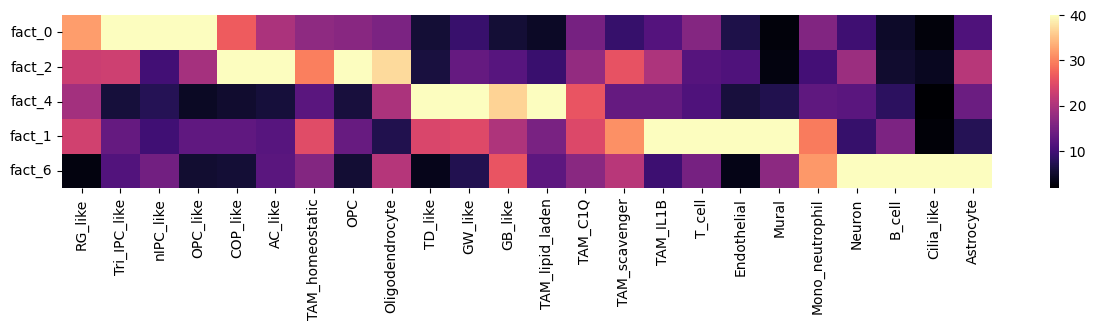

In [33]:
test_tab3 = test_tab3[cts]
plt.figure(figsize=(15, 2.25))
sb.heatmap(test_tab3, annot=False, cmap="magma", fmt=".0f",linewidths=0, vmax=40)
# plt.savefig('figures/heatmap_nmf_cell2loc_pDG_all_celltypes_v2.pdf', bbox_inches='tight')
plt.show()

In [40]:
cts = ['AC_like','COP_like','TAM_homeostatic','TAM_IL1B',
            'nIPC_like','Tri_IPC_like',
            'OPC_like','RG_like','TAM_C1Q',
            
            'Mono_neutrophil','TAM_scavenger',
            'TAM_lipid_laden','TD_like','GW_like']

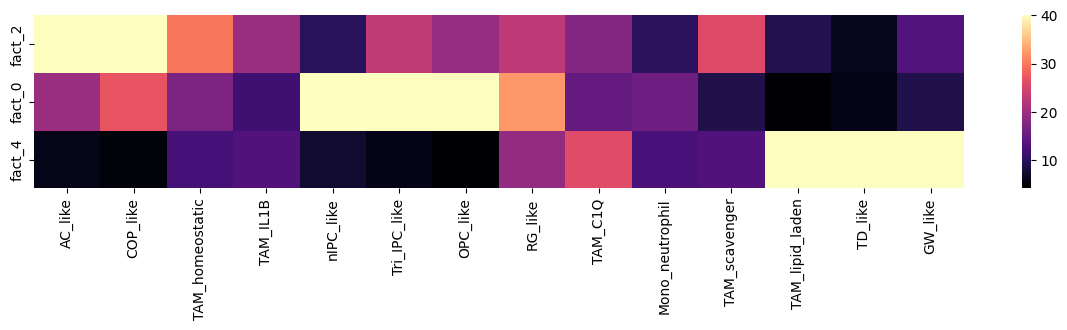

In [42]:
test_tab3 = test_tab3[cts]
test_tab3 = test_tab3.loc[['fact_2','fact_0',  'fact_4']]
plt.figure(figsize=(15, 2.25))
sb.heatmap(test_tab3, annot=False, cmap="magma", fmt=".0f",linewidths=0, vmax=40)
plt.savefig('figures/heatmap_nmf_cell2loc_pDG_subset.pdf', bbox_inches='tight')
plt.show()